# Regional payload tensor
Load four local COCO images and represent each image's 16 already-authenticated packets as a 44-channel spatial payload. This notebook does not embed payloads into pixels.

In [1]:
print("Kernel connected successfully")

Kernel connected successfully


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

repo_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(repo_root))

from kfrag.crypto import ProvenanceToken, create_packets
from kfrag.data import CocoImageDataset
from kfrag.payload import batch_packets_to_grid, expand_payload_grid, grid_to_packets

In [3]:
dataset = CocoImageDataset(repo_root / 'data/raw/coco_val2017_100')
batch = next(iter(DataLoader(dataset, batch_size=4, shuffle=False, num_workers=0)))
print('Image batch:', tuple(batch['image'].shape))

Image batch: (4, 3, 256, 256)


In [4]:
# The key remains private in memory and is deliberately never displayed.
secret_key = b'notebook-only-demonstration-key'
tokens = [ProvenanceToken.generate(issuer_id=42, version=1) for _ in range(4)]
assert len({token.pack() for token in tokens}) == 4
packet_batches = [create_packets(token, secret_key) for token in tokens]
payload = batch_packets_to_grid(packet_batches)
expanded_payload = expand_payload_grid(payload, image_size=256)
print('Payload batch:', tuple(payload.shape))
print('Expanded payload batch:', tuple(expanded_payload.shape))

Payload batch: (4, 44, 4, 4)
Expanded payload batch: (4, 44, 256, 256)


In [5]:
reconstructed = [grid_to_packets(image_grid) for image_grid in payload]
assert all(tuple(decoded) == original for decoded, original in zip(reconstructed, packet_batches))
print('All packet fields round-trip exactly.')

All packet fields round-trip exactly.


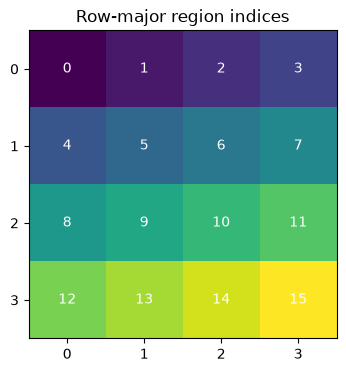

In [6]:
region_indices = np.arange(16).reshape(4, 4)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(region_indices, cmap='viridis')
for row in range(4):
    for column in range(4):
        ax.text(column, row, str(region_indices[row, column]), ha='center', va='center', color='white')
ax.set(title='Row-major region indices', xticks=range(4), yticks=range(4))
plt.show()

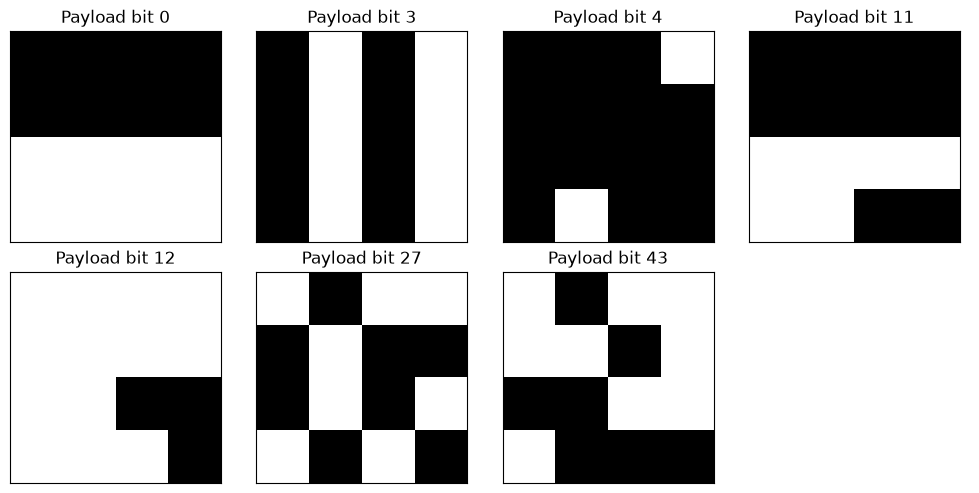

In [7]:
selected_bits = [0, 3, 4, 11, 12, 27, 43]
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, bit_index in zip(axes.flat, selected_bits):
    ax.imshow(payload[0, bit_index].cpu(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Payload bit {bit_index}')
    ax.set_xticks([]); ax.set_yticks([])
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()